# Solving a Nonlinear System Numerically - The Lorenz Attractor (RK4)

**Methods:** 4th-order Runge–Kutta, NumPy, Matplotlib, Plotly (3D)

### Overview
This notebook uses numerical methods to solve and investigate the behavior of the nonlinear Lorenz system using the 4th-order Runge–Kutta method:

\begin{align*}
    \frac{dX}{dt} &=-\sigma X + \sigma Y \\
    \frac{dY}{dt} &=-XZ+rX-Y \\
    \frac{dZ}{dt} &=XY-bZ
\end{align*}

----

Refer to the article by Edward N. Lorenz. Deterministic nonperiodic flow. Journal of the Atmospheric Sciences, 20(2):130–141, 1963

Lorenz discovered that weather is a non-linear phenomenon. Through a numerical weather model, he established weather's strong sensitivity to initial conditions. Because of this extreme sensitivity, he told the public that long-term weather forecasting is impossible by introducing the "butterfly effect." He stated that a flapping of a butterfly's wings in China leads to unpredictable changes in U.S. weather after a few days. His pioneering work paved the way to the concept of "chaos theory".

$X$, $Y$, and $Z$ are non-dimensional dependent variables representing convective intensity, temperature difference between descending and ascending currents, and the difference in the vertical temperature profile, respectively. The internal parameters $\sigma$, $r$, and $b$, represent the Prandtl number, Rayleigh number, and geometric factor, respectively. In this exercise, we won't be discussing the details of these parameters. Instead, we will analyze the behaviour of the dependent variables to investigate the chaotic behaviour of the system.

The initial conditions and internal parameters are given as follows:

$X(t=0)$ = `Xinit` = 1.0

$Y(t=0)$ = `Yinit` = 1.0

$Z(t=0)$ = `Zinit` = 1.0

$\sigma$ = `sigma` = 10.0

$r$ = `r` = 28.0

$b$ = `b` = 8.0/3.0

This notebook uses a 4th-order Runge-Kutta model to numerically solve the above nonlinear equations and calculate the dependent variables from 0.0 to 200.0 time-units with a spacing of 0.01 time-units. The behavior of the system is then investigated by modifying the initial conditions by small amounts, such as +0.001, -0.001, and +0.0001, to examine its sensitivity to initial conditions. Finally, the resulting trajectories are visualized to demonstrate the famous strange attractor known as the "Lorenz Attractor".

Reference:

https://www.britannica.com/biography/Edward-Lorenz

https://plato.stanford.edu/entries/chaos/.

---

### Program

#### Importing necessary modules and define common parameters

In [1]:
import matplotlib.pyplot as plt
import numpy as np

sigma = 10.0
b = 8.0/3.0
r = 28.0
dt = 0.001
tinit = 0.0
tend = 200.0

#### Defining the Lorenz system and the RK4 integrator.

In [2]:
def dXdt(X, Y, Z):
  return -sigma*X + sigma*Y

def dYdt(X, Y, Z):
  return -X*Z + r*X - Y

def dZdt(X, Y, Z):
  return X*Y -b*Z

def rk4(dt,tend,Xinit,Yinit,Zinit):
    t = np.arange(tinit,tend+dt,dt)
    X = np.empty_like(t)
    Y = np.empty_like(t)
    Z = np.empty_like(t)
    X[0] = Xinit
    Y[0] = Yinit
    Z[0] = Zinit
    for i in range(0,t.shape[0]-1):
        h1 = dt*dXdt(X[i], Y[i], Z[i])
        k1 = dt*dYdt(X[i], Y[i], Z[i])
        l1 = dt*dZdt(X[i], Y[i], Z[i])
        h2 = dt*dXdt(X[i] + h1/2.0, Y[i] + k1/2.0, Z[i] + l1/2.0)
        k2 = dt*dYdt(X[i] + h1/2.0, Y[i] + k1/2.0, Z[i] + l1/2.0)
        l2 = dt*dZdt(X[i] + h1/2.0, Y[i] + k1/2.0, Z[i] + l1/2.0)
        h3 = dt*dXdt(X[i] + h2/2.0, Y[i] + k2/2.0, Z[i] + l2/2.0)
        k3 = dt*dYdt(X[i] + h2/2.0, Y[i] + k2/2.0, Z[i] + l2/2.0)
        l3 = dt*dZdt(X[i] + h2/2.0, Y[i] + k2/2.0, Z[i] + l2/2.0)
        h4 = dt*dXdt(X[i] + h3, Y[i] + k3, Z[i] + l3)
        k4 = dt*dYdt(X[i] + h3, Y[i] + k3, Z[i] + l3)
        l4 = dt*dZdt(X[i] + h3, Y[i] + k3, Z[i] + l3)
        X[i+1] = X[i] + (h1 + h2*2.0 + h3*2.0 + h4)/6.0
        Y[i+1] = Y[i] + (k1 + k2*2.0 + k3*2.0 + k4)/6.0
        Z[i+1] = Z[i] + (l1 + l2*2.0 + l3*2.0 + l4)/6.0
    return t,X,Y,Z

## Initial Condition (Xinit = 1.0, Yinit = 1.0, Zinit =  1.0)

### Applying the function above

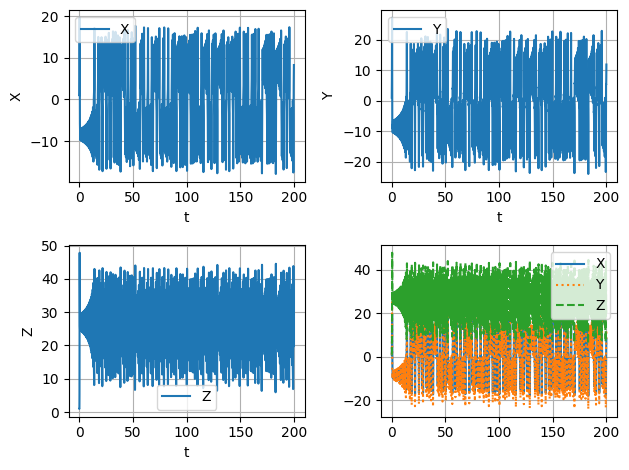

In [3]:
t,X,Y,Z = rk4(dt, tend, 1.0, 1.0, 1.0)
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,X, label = 'X')
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,Y, label = 'Y')
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('Y')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,Z, label = 'Z')
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('Z')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,X, label = 'X')
ax[1,1].plot(t,Y,linestyle = 'dotted', label = 'Y')
ax[1,1].plot(t,Z,linestyle = 'dashed', label = 'Z')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

### Visualizing the data in 3D

##### Default option

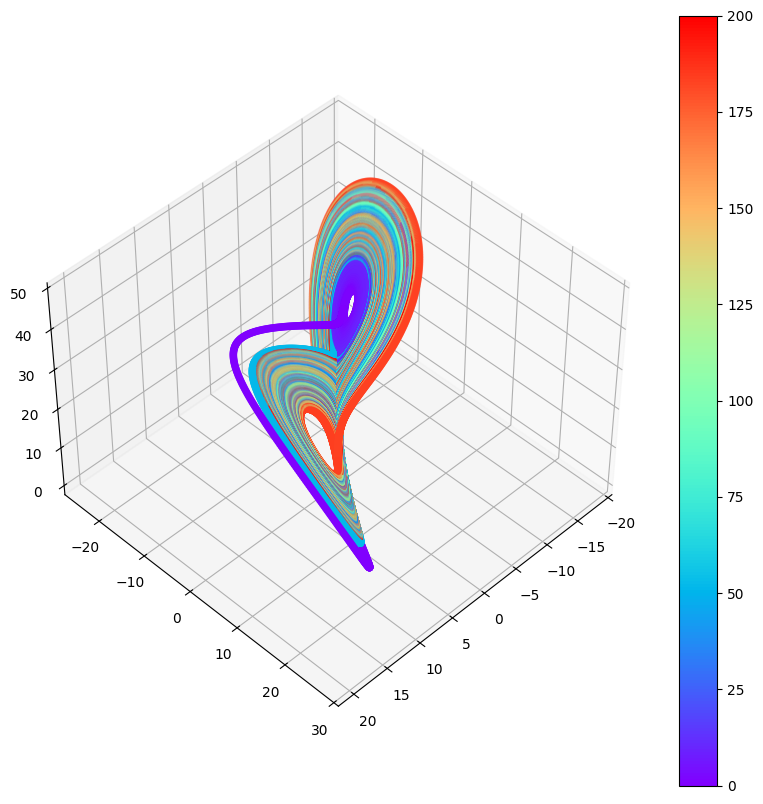

In [4]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.view_init(elev=45, azim=45) #adjust for rotation
p = ax.scatter(X,Y,Z,c=t,cmap='rainbow')
fig.colorbar(p)

##### Interactive option to visualize the data

In [5]:
%matplotlib inline

In [6]:
import plotly.graph_objects as go
import numpy as np

stride = 30  #keep 1 in every 30 points
fig = go.Figure(data=[go.Scatter3d(
    x=X[::stride], y=Y[::stride], z=Z[::stride],
    mode='markers', marker=dict(
        size=1,
        color=t[::stride],
        colorscale='Viridis',
        opacity=0.8, colorbar=dict(thickness=20)
    ))])
fig.show()

## Initial Condition (Xinit = 1.0 + 0.001, Yinit = 1.0 + 0.001, Zinit = 1.0 + 0.001)

### Applying the function above

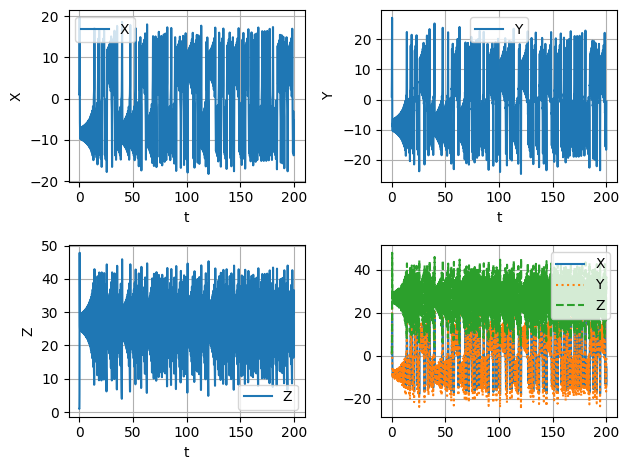

In [7]:
t,X,Y,Z = rk4(dt, tend, 1.0+0.001, 1.0+0.001, 1.0+0.001)
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,X, label = 'X')
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,Y, label = 'Y')
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('Y')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,Z, label = 'Z')
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('Z')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,X, label = 'X')
ax[1,1].plot(t,Y,linestyle = 'dotted', label = 'Y')
ax[1,1].plot(t,Z,linestyle = 'dashed', label = 'Z')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

### Visualizing the data in 3D

##### Default option

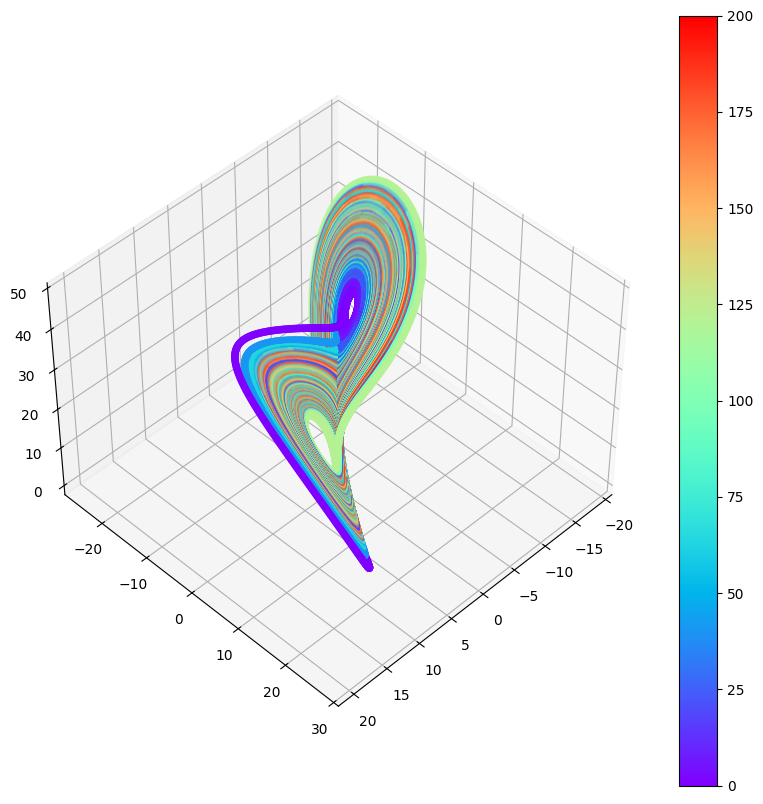

In [8]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.view_init(elev=45, azim=45) #adjust for rotation
p = ax.scatter(X,Y,Z,c=t,cmap='rainbow')
fig.colorbar(p)

##### Interactive option to visualize the data

In [9]:
import plotly.graph_objects as go
import numpy as np

stride = 30
fig = go.Figure(data=[go.Scatter3d(x=X[::stride], y=Y[::stride], z=Z[::stride],
                                   mode='markers',marker=dict(
        size=1,
        color=t[::stride],
        colorscale='Viridis',
        opacity=0.8,colorbar=dict(thickness=20)
    ))])
fig.show()

## Initial Condition (Xinit = 1.0 - 0.001, Yinit = 1.0 - 0.001, Zinit = 1.0 - 0.001)

### Applying the function above

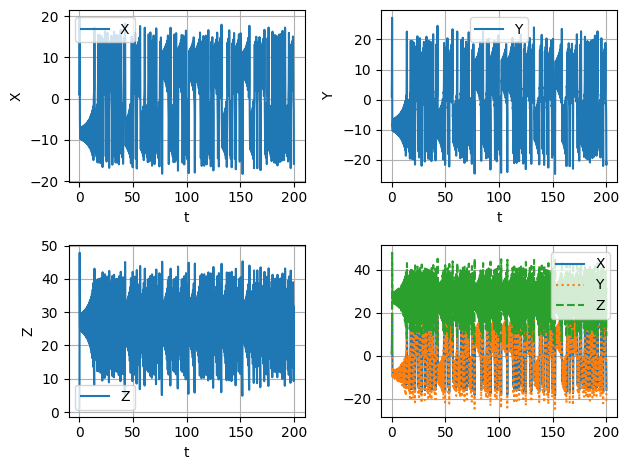

In [10]:
t,X,Y,Z = rk4(dt, tend, 1.0-0.001, 1.0-0.001, 1.0-0.001)
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,X, label = 'X')
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,Y, label = 'Y')
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('Y')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,Z, label = 'Z')
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('Z')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,X, label = 'X')
ax[1,1].plot(t,Y,linestyle = 'dotted', label = 'Y')
ax[1,1].plot(t,Z,linestyle = 'dashed', label = 'Z')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

### Visualizing the data in 3D

##### Default option

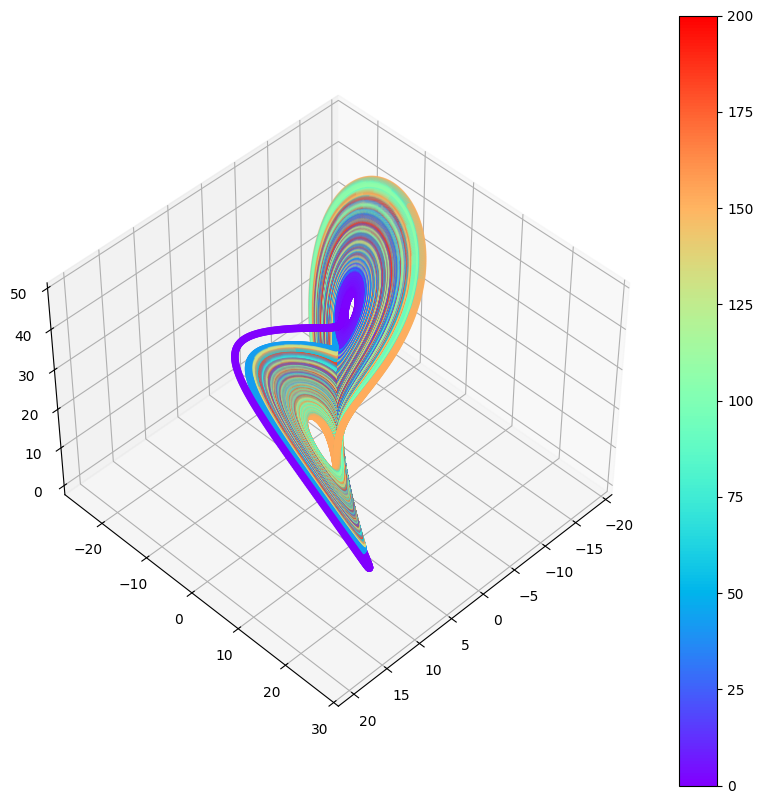

In [11]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.view_init(elev=45, azim=45) #adjust for rotation
p = ax.scatter(X,Y,Z,c=t,cmap='rainbow')
fig.colorbar(p)

##### Interactive option to visualize the data

In [12]:
import plotly.graph_objects as go
import numpy as np

stride = 30
fig = go.Figure(data=[go.Scatter3d(x=X[::stride], y=Y[::stride], z=Z[::stride],
                                   mode='markers',marker=dict(
        size=1,
        color=t[::stride],
        colorscale='Viridis',
        opacity=0.8,colorbar=dict(thickness=20)
    ))])
fig.show()

## Initial Condition (Xinit = 1.0 + 0.0001, Yinit = 1.0 + 0.0001, Zinit = 1.0 + 0.0001)

### Applying the function above

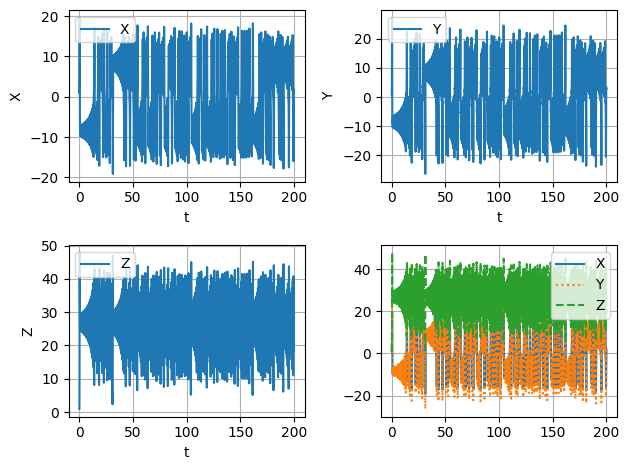

In [13]:
t,X,Y,Z = rk4(dt, tend, 1.0+0.0001, 1.0+0.0001, 1.0+0.0001)
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,X, label = 'X')
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,Y, label = 'Y')
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('Y')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,Z, label = 'Z')
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('Z')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,X, label = 'X')
ax[1,1].plot(t,Y,linestyle = 'dotted', label = 'Y')
ax[1,1].plot(t,Z,linestyle = 'dashed', label = 'Z')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

### Visualizing the data in 3D

##### Default option

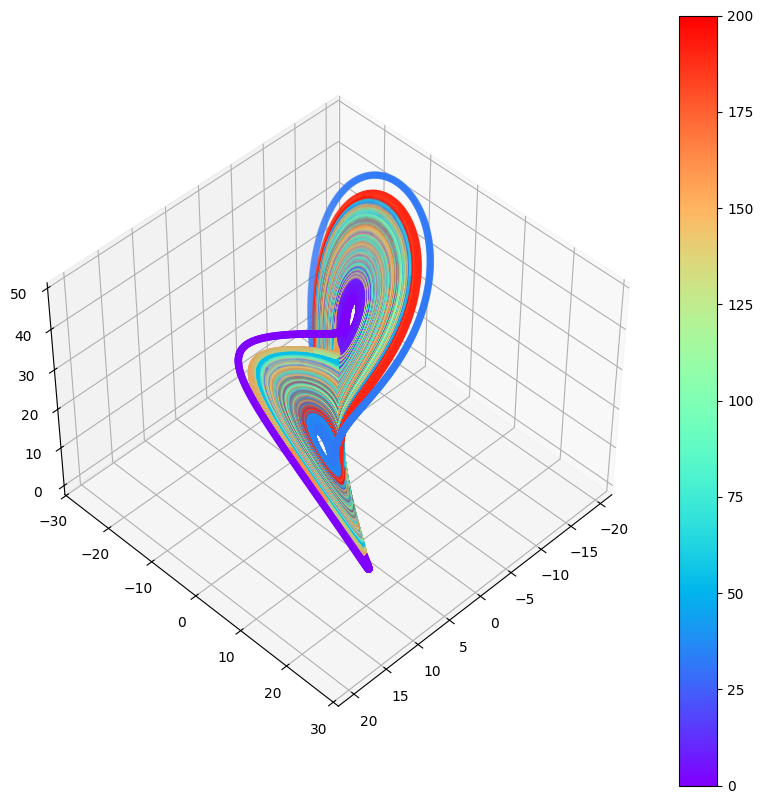

In [14]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.view_init(elev=45, azim=45) #adjust for rotation
p = ax.scatter(X,Y,Z,c=t,cmap='rainbow')
fig.colorbar(p)

##### Interactive option to visualize the data

In [15]:
import plotly.graph_objects as go
import numpy as np

stride = 30
fig = go.Figure(data=[go.Scatter3d(x=X[::stride], y=Y[::stride], z=Z[::stride],
                                   mode='markers',marker=dict(
        size=1,
        color=t[::stride],                # set color to an array/list of desired values
        colorscale='Viridis',   # choose a colorscale
        opacity=0.8,colorbar=dict(thickness=20)
    ))])
fig.show()

## Comparing

To compare the system's behavior under different initial conditions more clearly, the resulting trajectories are displayed side by side. The initial conditions used for each case are:

`X1, Y1, Z1 = 1.0, 1.0, 1.0`,

`X2, Y2, Z2 = 1.0 + 0.001, 1.0 + 0.001, 1.0 + 0.001`,

`X3, Y3, Z3 = 1.0 - 0.001, 1.0 - 0.001, 1.0 - 0.001`,

`X4, Y4, Z4 = 1.0 + 0.0001, 1.0 + 0.0001, 1.0 + 0.0001`

### `t` from 0 to 200

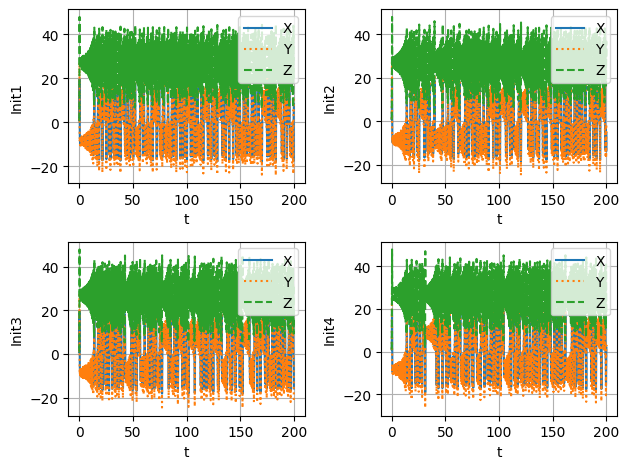

In [16]:
t,X1,Y1,Z1 = rk4(dt, tend, 1.0, 1.0, 1.0)
t,X2,Y2,Z2 = rk4(dt, tend, 1.0+0.001, 1.0+0.001, 1.0+0.001)
t,X3,Y3,Z3 = rk4(dt, tend, 1.0-0.001, 1.0-0.001, 1.0-0.001)
t,X4,Y4,Z4 = rk4(dt, tend, 1.0+0.0001, 1.0+0.0001, 1.0+0.0001)
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,X1, label = 'X')
ax[0,0].plot(t,Y1,linestyle = 'dotted', label = 'Y')
ax[0,0].plot(t,Z1,linestyle = 'dashed', label = 'Z')
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('Init1')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,X2, label = 'X')
ax[0,1].plot(t,Y2,linestyle = 'dotted', label = 'Y')
ax[0,1].plot(t,Z2,linestyle = 'dashed', label = 'Z')
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('Init2')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,X3, label = 'X')
ax[1,0].plot(t,Y3,linestyle = 'dotted', label = 'Y')
ax[1,0].plot(t,Z3,linestyle = 'dashed', label = 'Z')
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('Init3')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,X4, label = 'X')
ax[1,1].plot(t,Y4,linestyle = 'dotted', label = 'Y')
ax[1,1].plot(t,Z4,linestyle = 'dashed', label = 'Z')
ax[1,1].set_xlabel('t')
ax[1,1].set_ylabel('Init4')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

We can observe that all of them have quite similar beginnings, but after the interval around `t = 25`, the differences become distinct and seem like it become disordered.

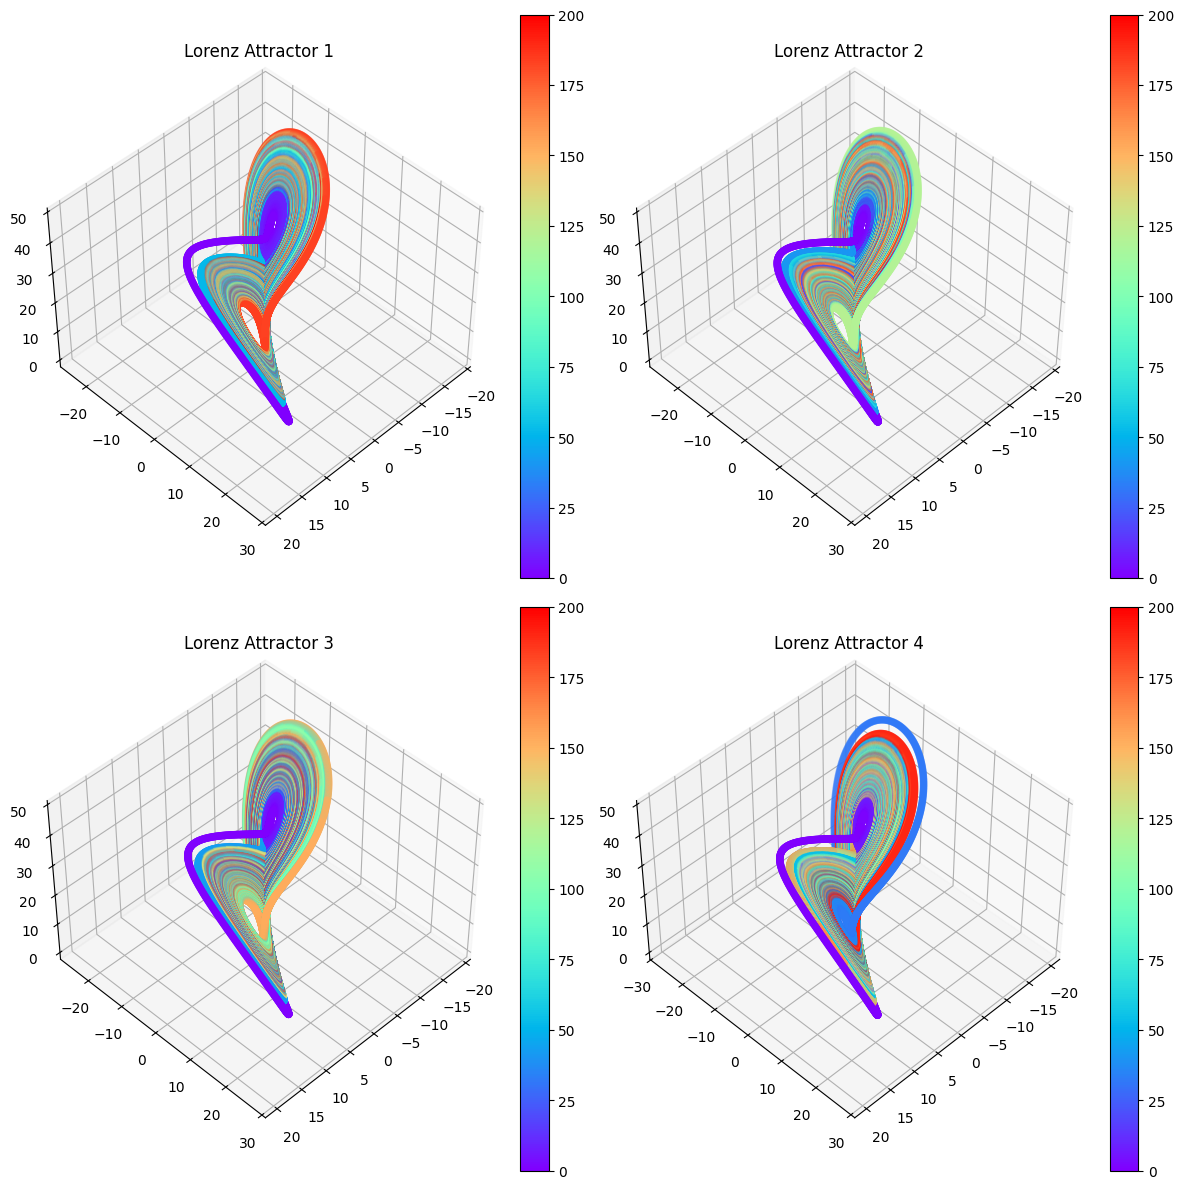

In [17]:
fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.view_init(elev=45, azim=45)
p1 = ax1.scatter(X1, Y1, Z1, c=t, cmap='rainbow')
fig.colorbar(p1, ax=ax1)
ax1.set_title("Lorenz Attractor 1")

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.view_init(elev=45, azim=45)
p2 = ax2.scatter(X2, Y2, Z2, c=t, cmap='rainbow')
fig.colorbar(p2, ax=ax2)
ax2.set_title("Lorenz Attractor 2")

ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.view_init(elev=45, azim=45)
p3 = ax3.scatter(X3, Y3, Z3, c=t, cmap='rainbow')
fig.colorbar(p3, ax=ax3)
ax3.set_title("Lorenz Attractor 3")

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.view_init(elev=45, azim=45)
p4 = ax4.scatter(X4, Y4, Z4, c=t, cmap='rainbow')
fig.colorbar(p4, ax=ax4)
ax4.set_title("Lorenz Attractor 4")

plt.tight_layout()
plt.show()


However, as we can see in the phase graph of X, Y, and Z, those values are still in order and follow the same pattern, not disorder as it seem in time series graphs.

### `t` from 150 to 200

For clearer vision of how the graphs behave we will zoom in for time interval of 150 to 200.

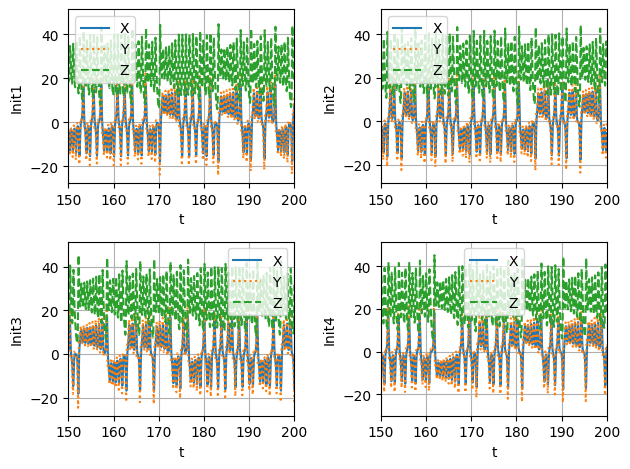

In [18]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,X1, label = 'X')
ax[0,0].plot(t,Y1,linestyle = 'dotted', label = 'Y')
ax[0,0].plot(t,Z1,linestyle = 'dashed', label = 'Z')
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('Init1')
ax[0,0].set_xlim(150, 200)
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,X2, label = 'X')
ax[0,1].plot(t,Y2,linestyle = 'dotted', label = 'Y')
ax[0,1].plot(t,Z2,linestyle = 'dashed', label = 'Z')
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('Init2')
ax[0,1].set_xlim(150, 200)
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,X3, label = 'X')
ax[1,0].plot(t,Y3,linestyle = 'dotted', label = 'Y')
ax[1,0].plot(t,Z3,linestyle = 'dashed', label = 'Z')
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('Init3')
ax[1,0].set_xlim(150, 200)
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,X4, label = 'X')
ax[1,1].plot(t,Y4,linestyle = 'dotted', label = 'Y')
ax[1,1].plot(t,Z4,linestyle = 'dashed', label = 'Z')
ax[1,1].set_xlabel('t')
ax[1,1].set_ylabel('Init4')
ax[1,1].set_xlim(150, 200)
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

As we can see here, when we zoom in and examine the interval from `t = 150` to `t = 200`, the differences between each case become cleary noticeable, even if they began from very small difference in their initial conditions. Which can be said that small difference in initial condition can lead to significant divergence over time (extreme sensitivity to initial conditions). However, the patterns still remain within a certain range of values, making an **ensemble forecast** possible.

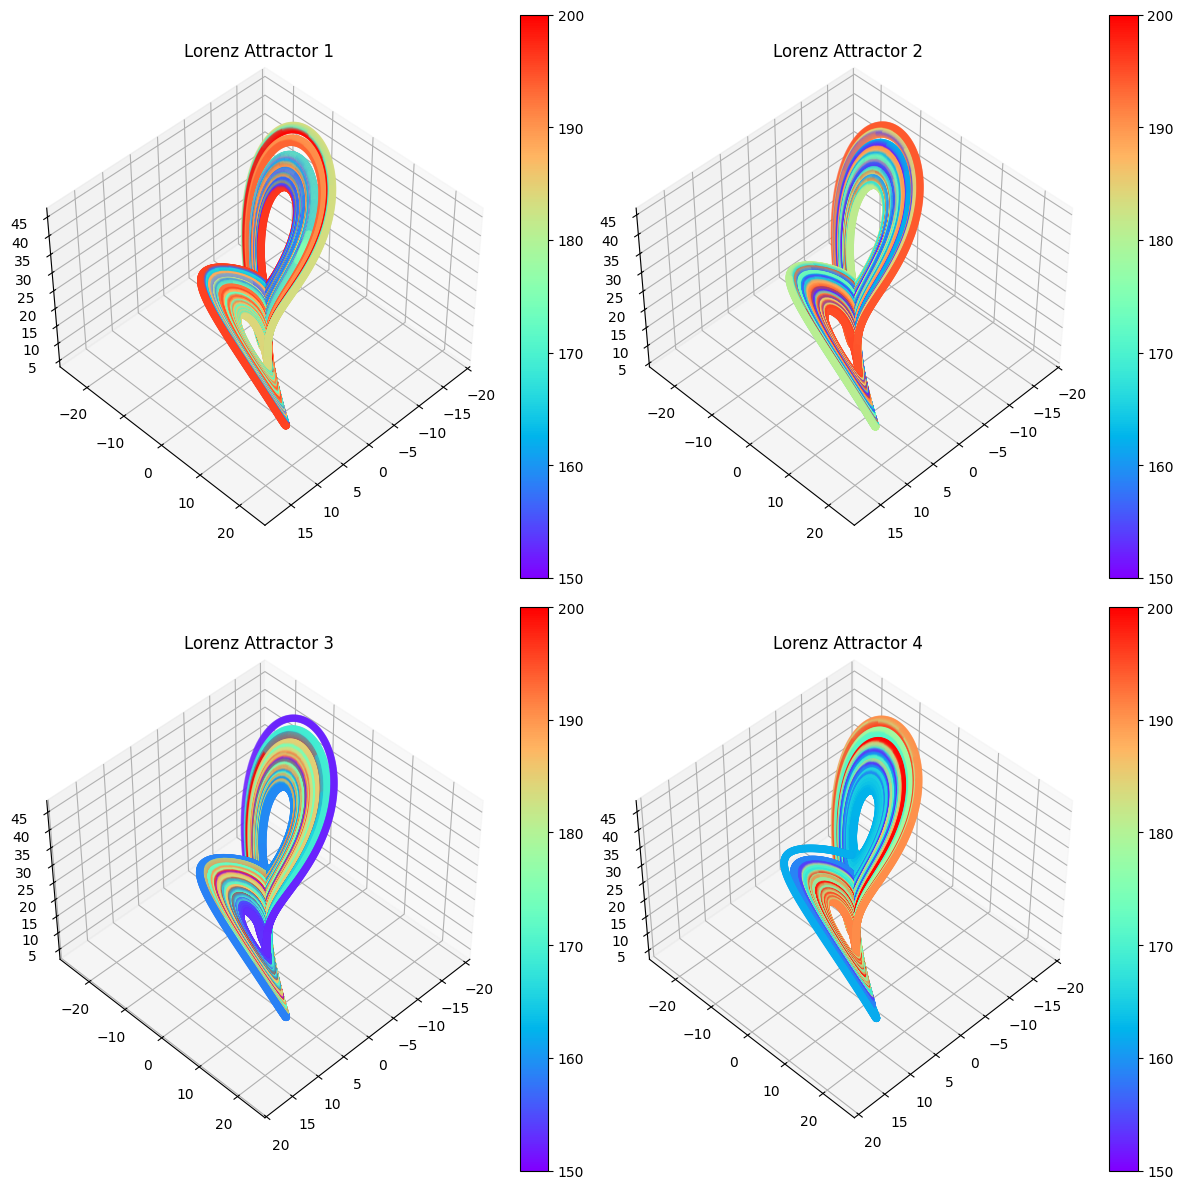

In [19]:
t_start = 150
start_index = np.where(t >= t_start)[0][0]
X1_s, Y1_s, Z1_s = X1[start_index:], Y1[start_index:], Z1[start_index:]
X2_s, Y2_s, Z2_s = X2[start_index:], Y2[start_index:], Z2[start_index:]
X3_s, Y3_s, Z3_s = X3[start_index:], Y3[start_index:], Z3[start_index:]
X4_s, Y4_s, Z4_s = X4[start_index:], Y4[start_index:], Z4[start_index:]
t_s = t[start_index:]

fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.view_init(elev=45, azim=45)
p1 = ax1.scatter(X1_s, Y1_s, Z1_s, c=t_s, cmap='rainbow')
fig.colorbar(p1, ax=ax1)
ax1.set_title("Lorenz Attractor 1")

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.view_init(elev=45, azim=45)
p2 = ax2.scatter(X2_s, Y2_s, Z2_s, c=t_s, cmap='rainbow')
fig.colorbar(p2, ax=ax2)
ax2.set_title("Lorenz Attractor 2")

ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.view_init(elev=45, azim=45)
p3 = ax3.scatter(X3_s, Y3_s, Z3_s, c=t_s, cmap='rainbow')
fig.colorbar(p3, ax=ax3)
ax3.set_title("Lorenz Attractor 3")

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.view_init(elev=45, azim=45)
p4 = ax4.scatter(X4_s, Y4_s, Z4_s, c=t_s, cmap='rainbow')
fig.colorbar(p4, ax=ax4)
ax4.set_title("Lorenz Attractor 4")

plt.tight_layout()
plt.show()


And the phase diagram still appears orderly and follows the same pattern of Lorenz Attractor.